In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2026-01-29_13-00-49/saved/checkpoint-epoch100.npy",
                                                            "+experiment=ipvae", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(1392.9572),
 'loss_batch_mean': np.float32(10.882478),
 'log_w': np.float32(-451515.6),
 'log_w_batch_mean': np.float32(-3527.4656)}

In [6]:
for data, _, _ in objects['datamodule'].test_dataloader():
    recons = objects['monad'](data)['x'].mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:377: UserWarning: Found vars in model but not guide: {'x'}
  check_model_guide_match(model_trace, guide_trace)


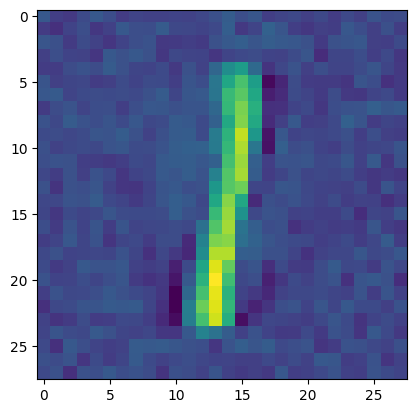

In [7]:
plt.imshow(recons[0].squeeze())

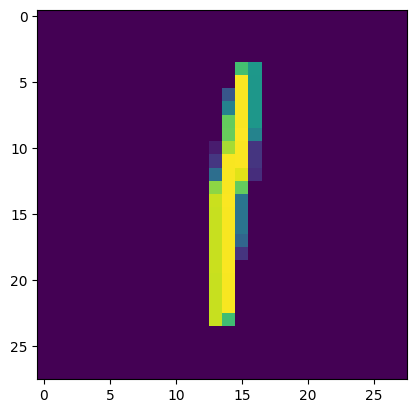

In [8]:
plt.imshow(data[0].squeeze())

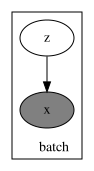

In [9]:
objects['monad'].render_model()